In [1]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect("../data/capstone_data.duckdb")


## Customers EDA

In [16]:
# 1. Customers overview
df_overview = con.execute("""
    SELECT Individual, COUNT(*) AS count
    FROM customers
    GROUP BY Individual
    ORDER BY count DESC
""").fetchdf()

# 2. Age distribution
df_age = con.execute("""
    SELECT Age
    FROM customers
    WHERE Age IS NOT NULL AND Age <> 0
""").fetchdf()

# 3. Relationship distribution
df_relationship = con.execute("""
    SELECT (RelationshipYears * 12 + RelationshipMonths) AS relationship_total_months
    FROM customers
    WHERE RelationshipYears IS NOT NULL
""").fetchdf()

# 4. Gender distribution
df_gender = con.execute("""
    SELECT Gender, COUNT(*) AS count
    FROM customers
    GROUP BY Gender
    ORDER BY count DESC
""").fetchdf()

# 5. Primary banking customer
df_primary = con.execute("""
    SELECT PrimaryBankingCustomerFlag, COUNT(*) AS count
    FROM customers
    GROUP BY PrimaryBankingCustomerFlag
    ORDER BY count DESC
""").fetchdf()

# 6. Card holdings 
df_cards = con.execute("""
    SELECT 'ATM Card' AS type, COUNT(*) AS count FROM customers WHERE ActiveATMCard = 'Y'
    UNION ALL
    SELECT 'Debit Card', COUNT(*) FROM customers WHERE ActiveDebitCard = 'Y'
    UNION ALL
    SELECT 'Credit Card', COUNT(*) FROM customers WHERE CreditCardAccount = 'Y'
""").fetchdf()

# 7. Account types 
df_accounts = con.execute("""
    SELECT 'Deposit' AS type, COUNT(*) AS count FROM customers WHERE DepositAccount = 'Y'
    UNION ALL
    SELECT 'Time Deposit', COUNT(*) FROM customers WHERE TimeDepositAccount = 'Y'
    UNION ALL
    SELECT 'Loan', COUNT(*) FROM customers WHERE LoanAccount = 'Y'
""").fetchdf()


# 8. Services enrolled
df_services = con.execute("""
    SELECT 'Bangor Wealth' AS type, COUNT(*) AS count FROM customers WHERE BangorWealth = TRUE
    UNION ALL
    SELECT 'Payroll', COUNT(*) FROM customers WHERE Payroll = TRUE
    UNION ALL
    SELECT 'Merchant', COUNT(*) FROM customers WHERE Merchant = TRUE
    UNION ALL
    SELECT 'TPS', COUNT(*) FROM customers WHERE TPS = TRUE
    UNION ALL
    SELECT 'Pling', COUNT(*) FROM customers WHERE PlingCustomer = TRUE
    UNION ALL
    SELECT 'ABLE', COUNT(*) FROM customers WHERE ABLECustomer = TRUE
""").fetchdf()


# 9. Cards per customer
df_cards_per_customer = con.execute("""
    SELECT 
        (CASE WHEN ActiveATMCard = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN ActiveDebitCard = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN CreditCardAccount = 'Y' THEN 1 ELSE 0 END) AS card_count
    FROM customers
""").fetchdf()

# 10. Accounts per customer
df_accounts_per_customer = con.execute("""
    SELECT 
        (CASE WHEN DepositAccount = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN TimeDepositAccount = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN LoanAccount = 'Y' THEN 1 ELSE 0 END) AS account_count
    FROM customers
""").fetchdf()

In [15]:
# Are zero-age customers clustered in certain segments or regions?
con.execute("""
    SELECT 
        COUNT(*) as zero_age_count,
        COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers) as pct
    FROM customers
    WHERE Age = 0 OR Age IS NULL
""").fetchdf()

,zero_age_count,pct
0,40533,14.641415


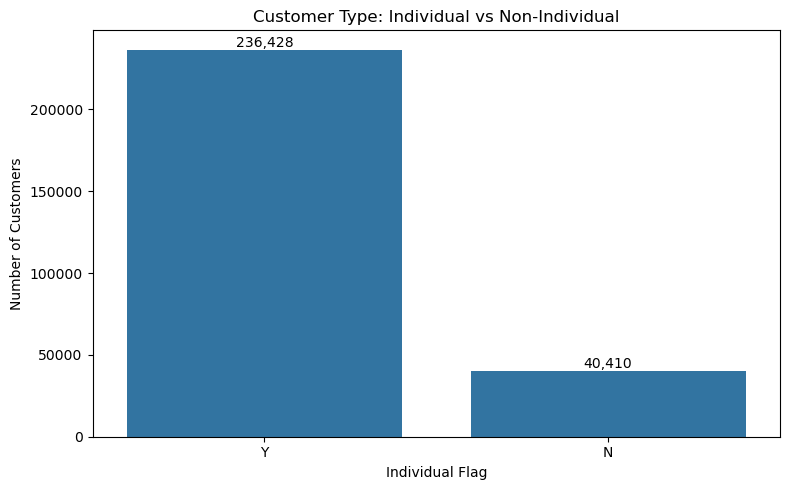

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_overview, x='Individual', y='count', ax=ax)
ax.set_title('Customer Type: Individual vs Non-Individual')
ax.set_xlabel('Individual Flag')
ax.set_ylabel('Number of Customers')
for i, row in df_overview.iterrows():
    ax.text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customertypes.png", dpi=150, bbox_inches='tight')
plt.show()

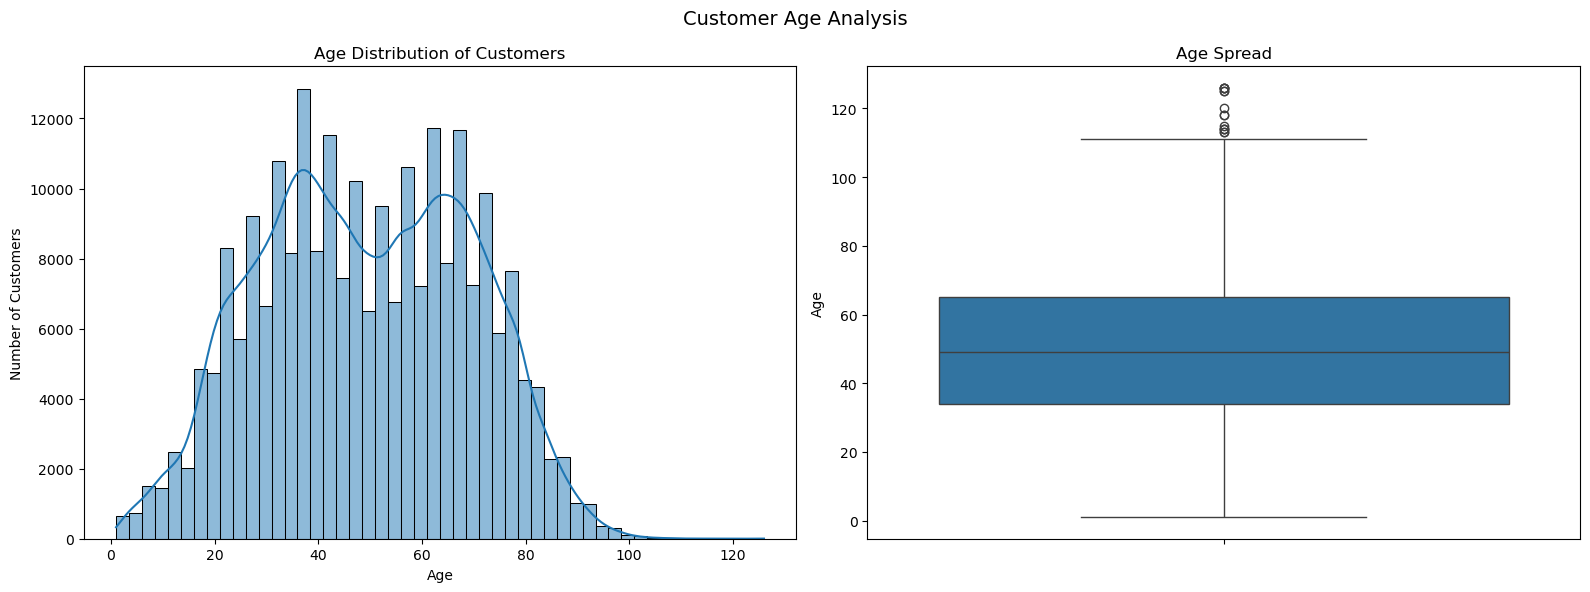

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df_age, x='Age', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution of Customers')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(data=df_age, y='Age', ax=axes[1])
axes[1].set_title('Age Spread')
axes[1].set_ylabel('Age')

plt.suptitle('Customer Age Analysis', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/customerage.png", dpi=150, bbox_inches='tight')
plt.show()

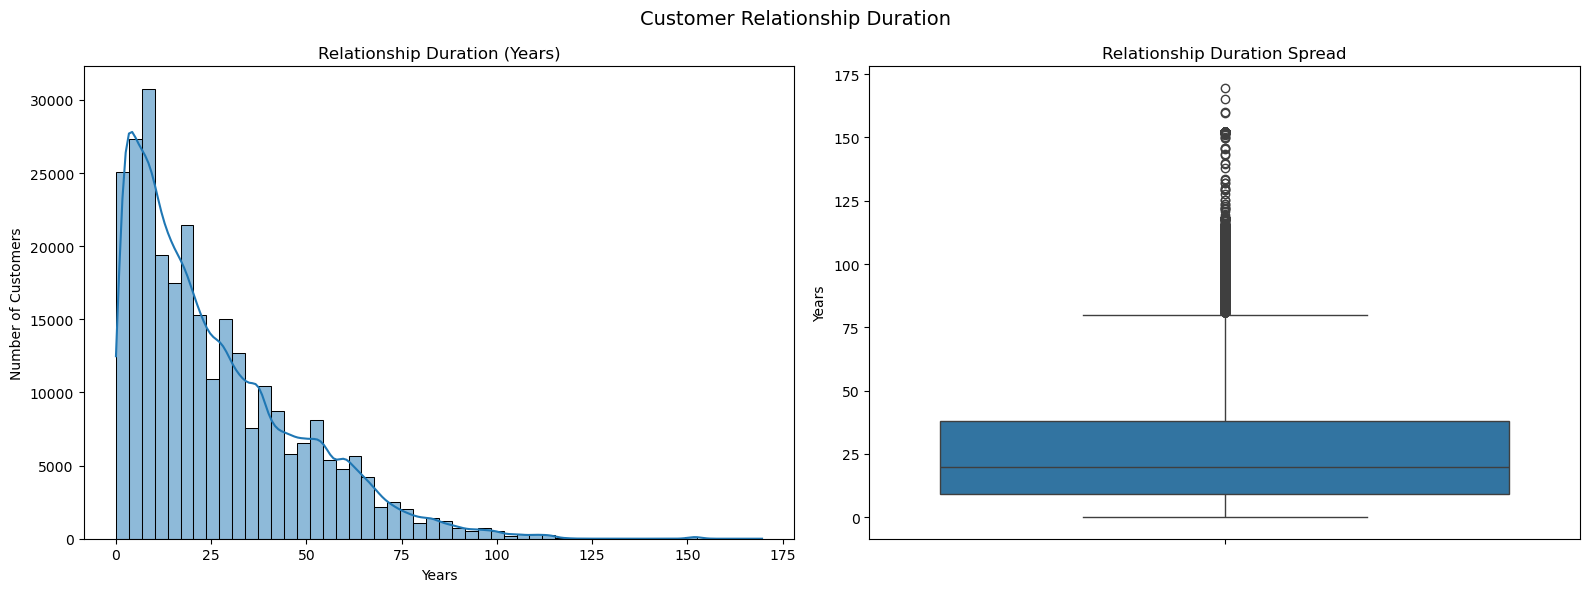

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df_relationship, x=df_relationship['relationship_total_months'] / 12, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Relationship Duration (Years)')
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(data=df_relationship, y=df_relationship['relationship_total_months']/12, ax=axes[1])
axes[1].set_title('Relationship Duration Spread')
axes[1].set_ylabel('Years')

plt.suptitle('Customer Relationship Duration', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/customerrelationship.png", dpi=150, bbox_inches='tight')
plt.show()

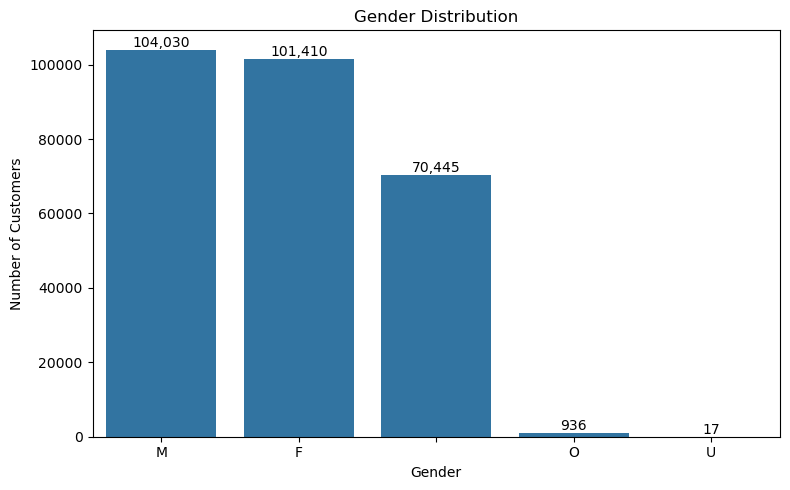

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_gender, x='Gender', y='count', ax=ax)
ax.set_title('Gender Distribution')
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Customers')
for i, row in df_gender.iterrows():
    ax.text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customergenders.png", dpi=150, bbox_inches='tight')
plt.show()

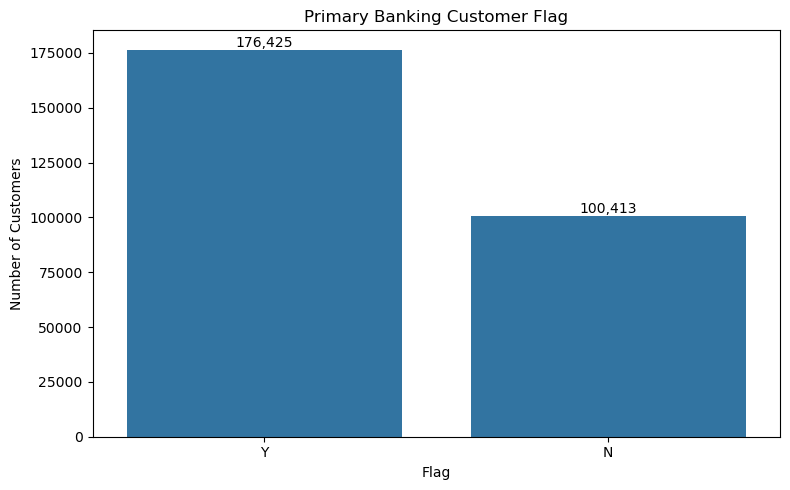

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_primary, x='PrimaryBankingCustomerFlag', y='count', ax=ax)
ax.set_title('Primary Banking Customer Flag')
ax.set_xlabel('Flag')
ax.set_ylabel('Number of Customers')
for i, row in df_primary.iterrows():
    ax.text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customerprimary.png", dpi=150, bbox_inches='tight')
plt.show()

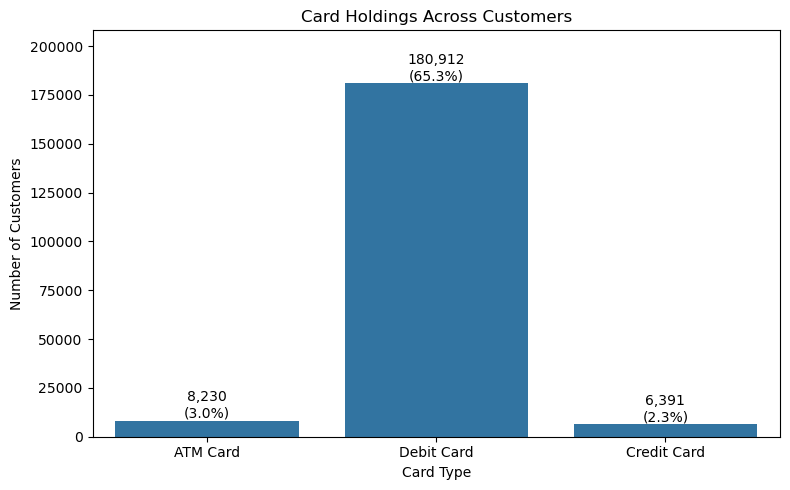

In [8]:
total = con.execute("SELECT COUNT(*) FROM customers").fetchone()[0]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_cards, x='type', y='count', ax=ax)
ax.set_title('Card Holdings Across Customers')
ax.set_xlabel('Card Type')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, df_cards['count'].max() * 1.15)
for i, row in df_cards.iterrows():
    pct = row['count'] / total * 100
    ax.text(i, row['count'], f"{row['count']:,}\n({pct:.1f}%)", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customercards.png", dpi=150, bbox_inches='tight')
plt.show()

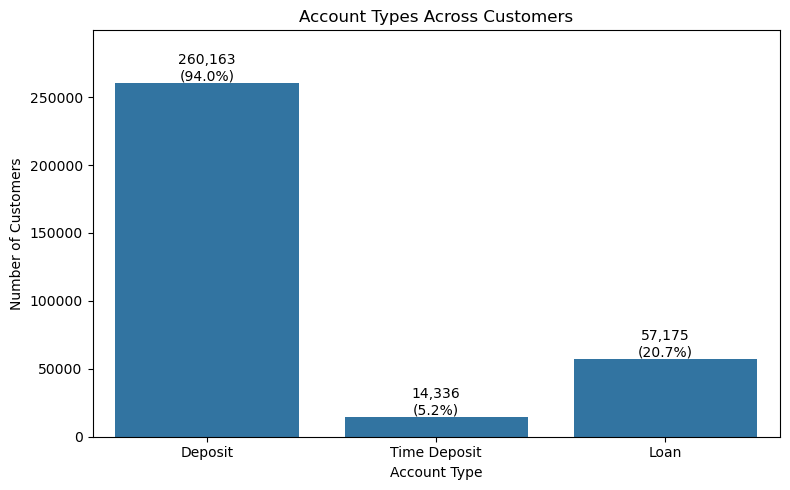

In [9]:
total = con.execute("SELECT COUNT(*) FROM customers").fetchone()[0]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_accounts, x='type', y='count', ax=ax)
ax.set_title('Account Types Across Customers')
ax.set_xlabel('Account Type')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, df_accounts['count'].max() * 1.15)
for i, row in df_accounts.iterrows():
    pct = row['count'] / total * 100
    ax.text(i, row['count'], f"{row['count']:,}\n({pct:.1f}%)", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customeraccounts.png", dpi=150, bbox_inches='tight')
plt.show()

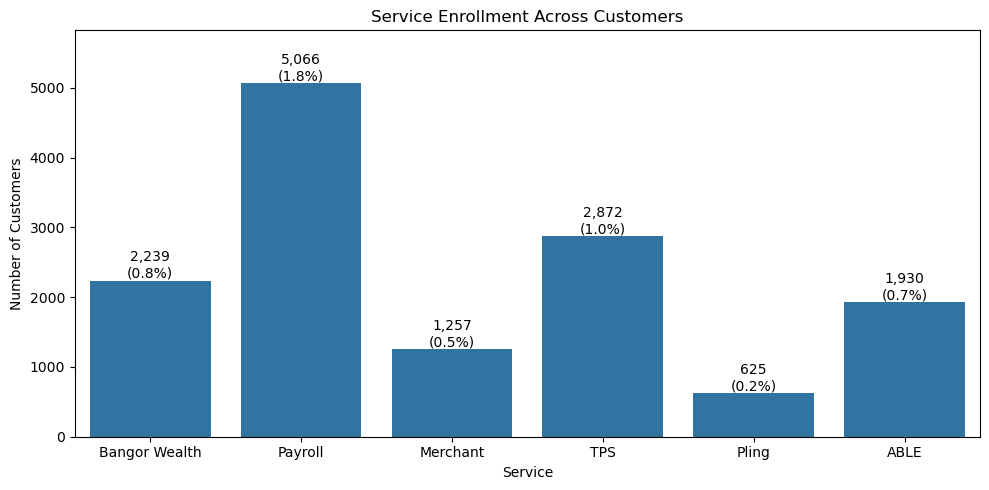

In [10]:
total = con.execute("SELECT COUNT(*) FROM customers").fetchone()[0]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_services, x='type', y='count', ax=ax)
ax.set_title('Service Enrollment Across Customers')
ax.set_xlabel('Service')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, df_services['count'].max() * 1.15)
for i, row in df_services.iterrows():
    pct = row['count'] / total * 100
    ax.text(i, row['count'], f"{row['count']:,}\n({pct:.1f}%)", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customerservices.png", dpi=150, bbox_inches='tight')
plt.show()

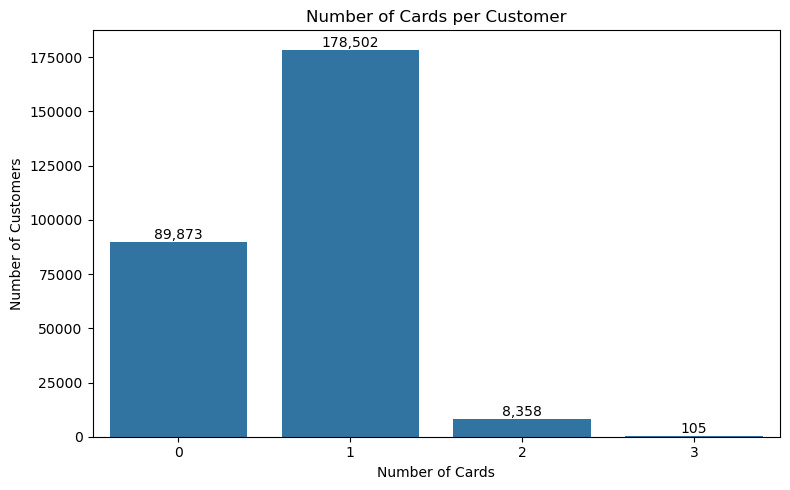

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_cards_per_customer, x='card_count', ax=ax)
ax.set_title('Number of Cards per Customer')
ax.set_xlabel('Number of Cards')
ax.set_ylabel('Number of Customers')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),
            f"{int(p.get_height()):,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customercards.png", dpi=150, bbox_inches='tight')
plt.show()

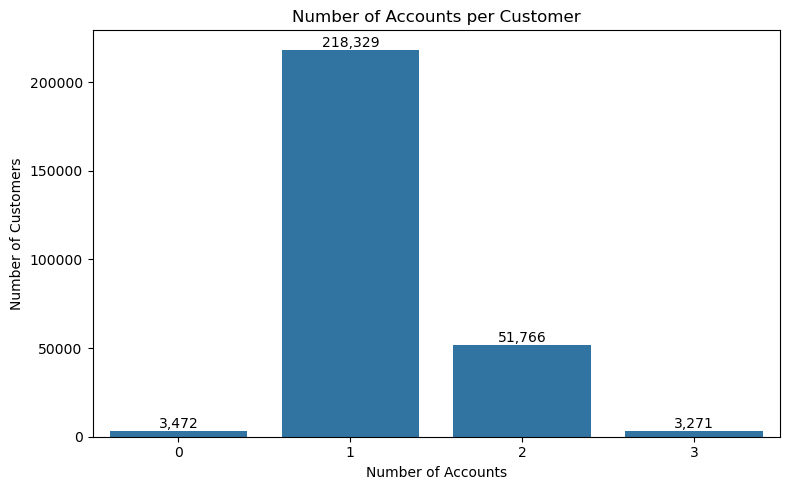

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_accounts_per_customer, x='account_count', ax=ax)
ax.set_title('Number of Accounts per Customer')
ax.set_xlabel('Number of Accounts')
ax.set_ylabel('Number of Customers')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),
            f"{int(p.get_height()):,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customeraccounts.png", dpi=150, bbox_inches='tight')
plt.show()

## Transactions EDA

In [37]:
# 1. Total transactions & basic stats
df_txn_overview = con.execute("""
    SELECT 
        COUNT(*) AS total_transactions,
        ROUND(AVG(Amount_Completed), 2) AS avg_amount,
        ROUND(MEDIAN(Amount_Completed), 2) AS median_amount,
        ROUND(MIN(Amount_Completed), 2) AS min_amount,
        ROUND(MAX(Amount_Completed), 2) AS max_amount
    FROM transactions
""").fetchdf()

# 2. Amount distribution
df_amount = con.execute("""
    SELECT Amount_Completed
    FROM transactions
    WHERE Amount_Completed IS NOT NULL
""").fetchdf()

# 3. Weekly classification (day of week)
df_weekly = con.execute("""
    SELECT DAYNAME(Transaction_Date) AS day_of_week, 
           DAYOFWEEK(Transaction_Date) AS day_num,
           COUNT(*) AS count
    FROM transactions
    GROUP BY day_of_week, day_num
    ORDER BY day_num
""").fetchdf()

# 4. Hourly classification
df_hourly = con.execute("""
    SELECT FLOOR(Time_Local_hhmmss / 10000) AS hour, 
           COUNT(*) AS count
    FROM transactions
    WHERE Time_Local_hhmmss IS NOT NULL
    GROUP BY hour
    ORDER BY hour
""").fetchdf()

df_hourly_amount = con.execute("""
    SELECT FLOOR(Time_Local_hhmmss / 10000) AS hour, 
           COUNT(*) AS count,
           ROUND(SUM(Amount_Completed), 2) AS total_amount,
           ROUND(AVG(Amount_Completed), 2) AS avg_amount
    FROM transactions
    WHERE Time_Local_hhmmss IS NOT NULL
    GROUP BY hour
    ORDER BY hour
""").fetchdf()

# 5. Transaction types
df_txn_type = con.execute("""
    SELECT Transaction_Type, Transaction_Type_Description, COUNT(*) AS count
    FROM transactions
    GROUP BY Transaction_Type, Transaction_Type_Description
    ORDER BY count DESC
""").fetchdf()

# 6. Transaction codes
df_txn_code = con.execute("""
    SELECT Transaction_Code, Transaction_Code_Description, COUNT(*) AS count
    FROM transactions
    GROUP BY Transaction_Code, Transaction_Code_Description
    ORDER BY count DESC
""").fetchdf()

# 7. Recurring transactions
df_recurring = con.execute("""
    SELECT Recurring_Trxn, COUNT(*) AS count
    FROM transactions
    GROUP BY Recurring_Trxn
    ORDER BY count DESC
""").fetchdf()

# 8. Transactions per customer
df_txn_buckets = con.execute("""
    SELECT 
        CASE 
            WHEN txn_count < 10 THEN '0-10'
            WHEN txn_count < 50 THEN '10-50'
            WHEN txn_count < 100 THEN '50-100'
            WHEN txn_count < 200 THEN '100-200'
            WHEN txn_count < 500 THEN '200-500'
            ELSE '500+'
        END AS bucket,
        COUNT(*) AS count
    FROM (
        SELECT CustomerID, COUNT(*) AS txn_count
        FROM transactions
        GROUP BY CustomerID
    )
    GROUP BY bucket
    ORDER BY MIN(txn_count)
""").fetchdf()

df_txn_per_customer = con.execute("""
    SELECT CustomerID, COUNT(*) AS txn_count
    FROM transactions
    GROUP BY CustomerID
""").fetchdf()

# 9. Transaction timeline (daily volume)
df_timeline = con.execute("""
    SELECT Transaction_Date, COUNT(*) AS count, 
           ROUND(SUM(Amount_Completed), 2) AS total_amount
    FROM transactions
    GROUP BY Transaction_Date
    ORDER BY Transaction_Date
""").fetchdf()

# 10. Transaction amount buckets
df_buckets = con.execute("""
    SELECT 
        CASE 
            WHEN Amount_Completed < 10 THEN '0-10'
            WHEN Amount_Completed < 50 THEN '10-50'
            WHEN Amount_Completed < 100 THEN '50-100'
            WHEN Amount_Completed < 500 THEN '100-500'
            WHEN Amount_Completed < 1000 THEN '500-1000'
            ELSE '1000+'
        END AS bucket,
        COUNT(*) AS count
    FROM transactions
    GROUP BY bucket
    ORDER BY MIN(Amount_Completed)
""").fetchdf()

# 11. Merchant category breakdown
df_merchant_cat = con.execute("""
    SELECT Merchant_Category, COUNT(*) AS count,
           ROUND(AVG(Amount_Completed), 2) AS avg_amount
    FROM transactions
    WHERE Merchant_Category IS NOT NULL
    GROUP BY Merchant_Category
    ORDER BY count DESC
    LIMIT 15
""").fetchdf()

# 12. Weekday vs weekend
df_weekday_weekend = con.execute("""
    SELECT 
        CASE WHEN DAYOFWEEK(Transaction_Date) IN (0, 6) THEN 'Weekend' ELSE 'Weekday' END AS day_type,
        COUNT(*) AS count,
        ROUND(AVG(Amount_Completed), 2) AS avg_amount
    FROM transactions
    GROUP BY day_type
""").fetchdf()

# 13. Monthly volume (Nov vs Dec vs Jan)
df_monthly = con.execute("""
    SELECT MONTHNAME(Transaction_Date) AS month,
           MONTH(Transaction_Date) AS month_num,
           COUNT(*) AS count,
           ROUND(SUM(Amount_Completed), 2) AS total_amount
    FROM transactions
    GROUP BY month, month_num
    ORDER BY month_num
""").fetchdf()

# 14. Avg transaction amount per customer (distribution)
df_avg_per_customer = con.execute("""
    SELECT CustomerID, 
           ROUND(AVG(Amount_Completed), 2) AS avg_amount,
           COUNT(*) AS txn_count
    FROM transactions
    GROUP BY CustomerID
""").fetchdf()

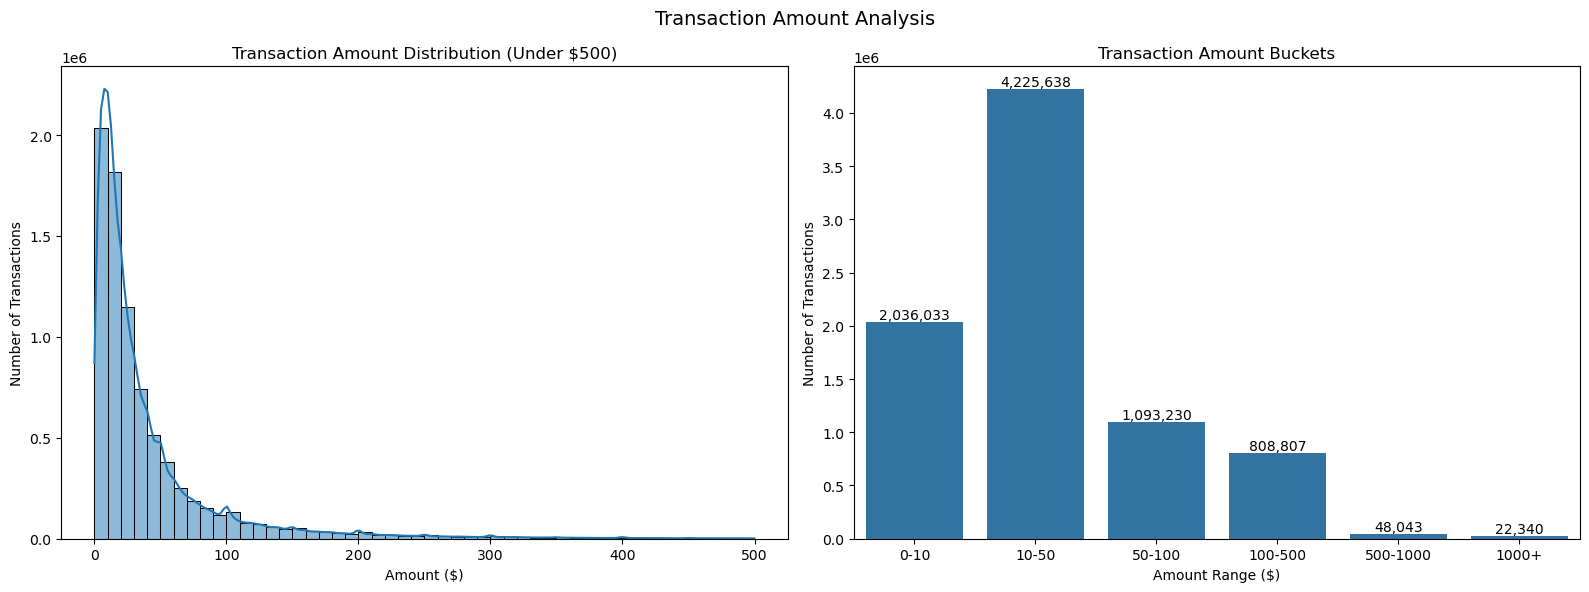

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

filtered = df_amount[df_amount['Amount_Completed'] < 500]
sns.histplot(data=filtered, x='Amount_Completed', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution (Under $500)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Number of Transactions')

sns.barplot(data=df_buckets, x='bucket', y='count', ax=axes[1])
axes[1].set_title('Transaction Amount Buckets')
axes[1].set_xlabel('Amount Range ($)')
axes[1].set_ylabel('Number of Transactions')
for i, row in df_buckets.iterrows():
    axes[1].text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')

plt.suptitle('Transaction Amount Analysis', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/txnamounts.png", dpi=150, bbox_inches='tight')
plt.show()

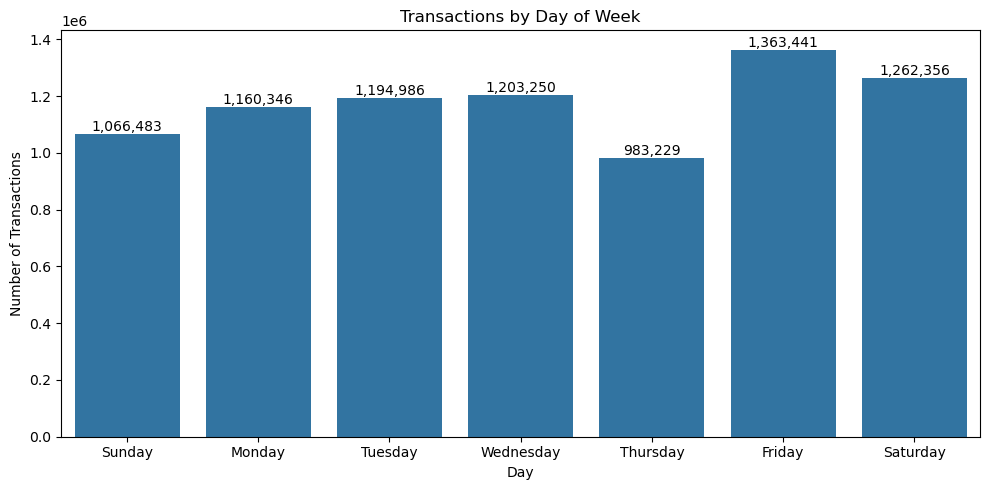

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_weekly, x='day_of_week', y='count', ax=ax)
ax.set_title('Transactions by Day of Week')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Transactions')
for i, row in df_weekly.iterrows():
    ax.text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/txnweekdays.png", dpi=150, bbox_inches='tight')
plt.show()

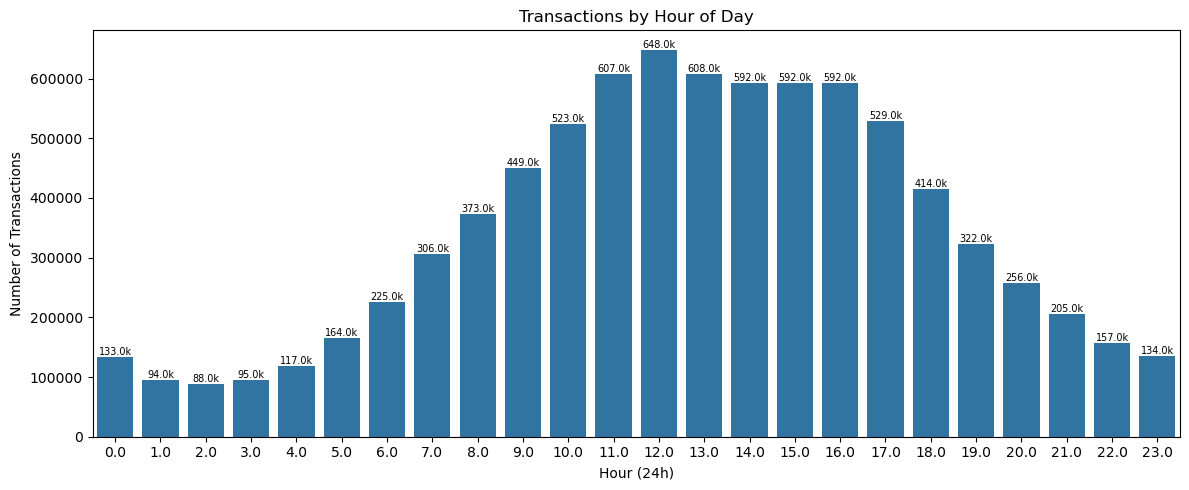

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_hourly, x='hour', y='count', ax=ax)
ax.set_title('Transactions by Hour of Day')
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Number of Transactions')
for i, row in df_hourly.iterrows():
    ax.text(i, row['count'], f"{row['count']//1000}k", ha='center', va='bottom', fontsize=7)
plt.tight_layout()
fig.savefig("../figs/eda/txnhours.png", dpi=150, bbox_inches='tight')
plt.show()

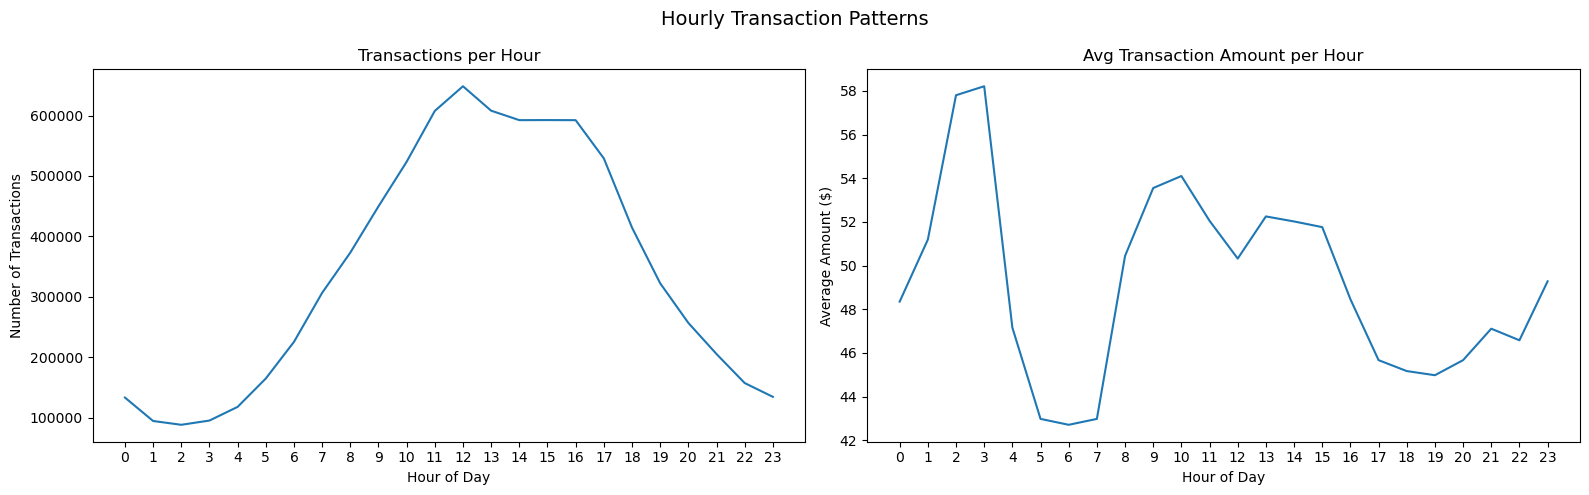

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df_hourly_amount['hour'], df_hourly_amount['count'])
axes[0].set_title('Transactions per Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(range(0, 24))

axes[1].plot(df_hourly_amount['hour'], df_hourly_amount['avg_amount'])
axes[1].set_title('Avg Transaction Amount per Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Amount ($)')
axes[1].set_xticks(range(0, 24))

plt.suptitle('Hourly Transaction Patterns', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/txn_hourly.png", dpi=150, bbox_inches='tight')
plt.show()

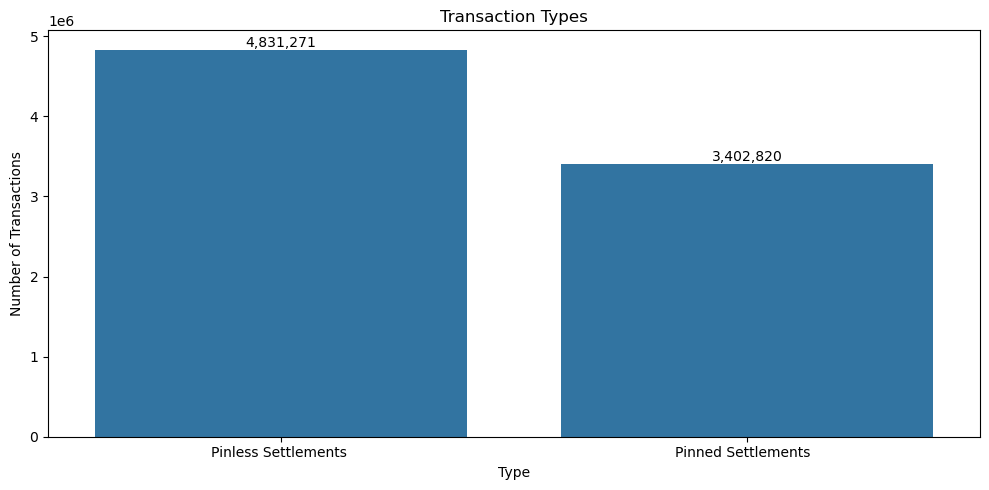

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_txn_type, x='Transaction_Type_Description', y='count', ax=ax)
ax.set_title('Transaction Types')
ax.set_xlabel('Type')
ax.set_ylabel('Number of Transactions')
for i, row in df_txn_type.iterrows():
    ax.text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/txnsettlements.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print(df_txn_code)

   Transaction_Code Transaction_Code_Description    count
0                40               D/C SETTLEMENT  4611094
1                20         POS Debit        Pri  3345105
2              3120         Pinless Bill Payment   220177
3                 0         POS Debit        Pri    57715


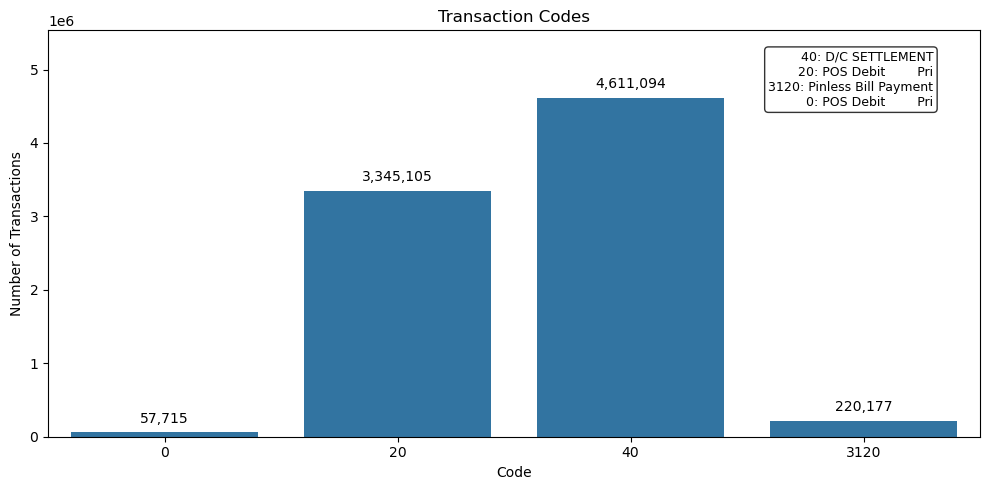

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_txn_code, x='Transaction_Code', y='count', ax=ax)
ax.set_title('Transaction Codes')
ax.set_xlabel('Code')
ax.set_ylabel('Number of Transactions')
ax.set_ylim(0, df_txn_code['count'].max() * 1.2)
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x):,}", padding=5)

legend_text = '\n'.join([f"{row['Transaction_Code']}: {row['Transaction_Code_Description']}" 
                         for _, row in df_txn_code.iterrows()])
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
fig.savefig("../figs/eda/txncodes.png", dpi=150, bbox_inches='tight')
plt.show()

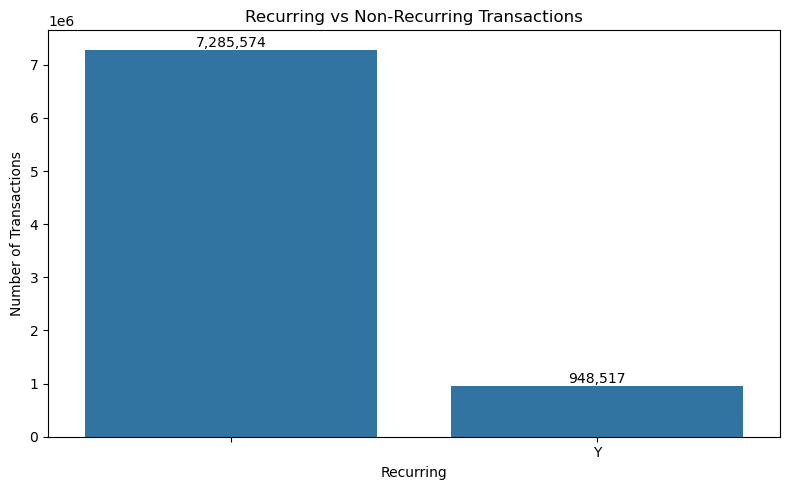

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_recurring, x='Recurring_Trxn', y='count', ax=ax)
ax.set_title('Recurring vs Non-Recurring Transactions')
ax.set_xlabel('Recurring')
ax.set_ylabel('Number of Transactions')
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x):,}")
plt.tight_layout()
fig.savefig("../figs/eda/txnrecurring.png", dpi=150, bbox_inches='tight')
plt.show()

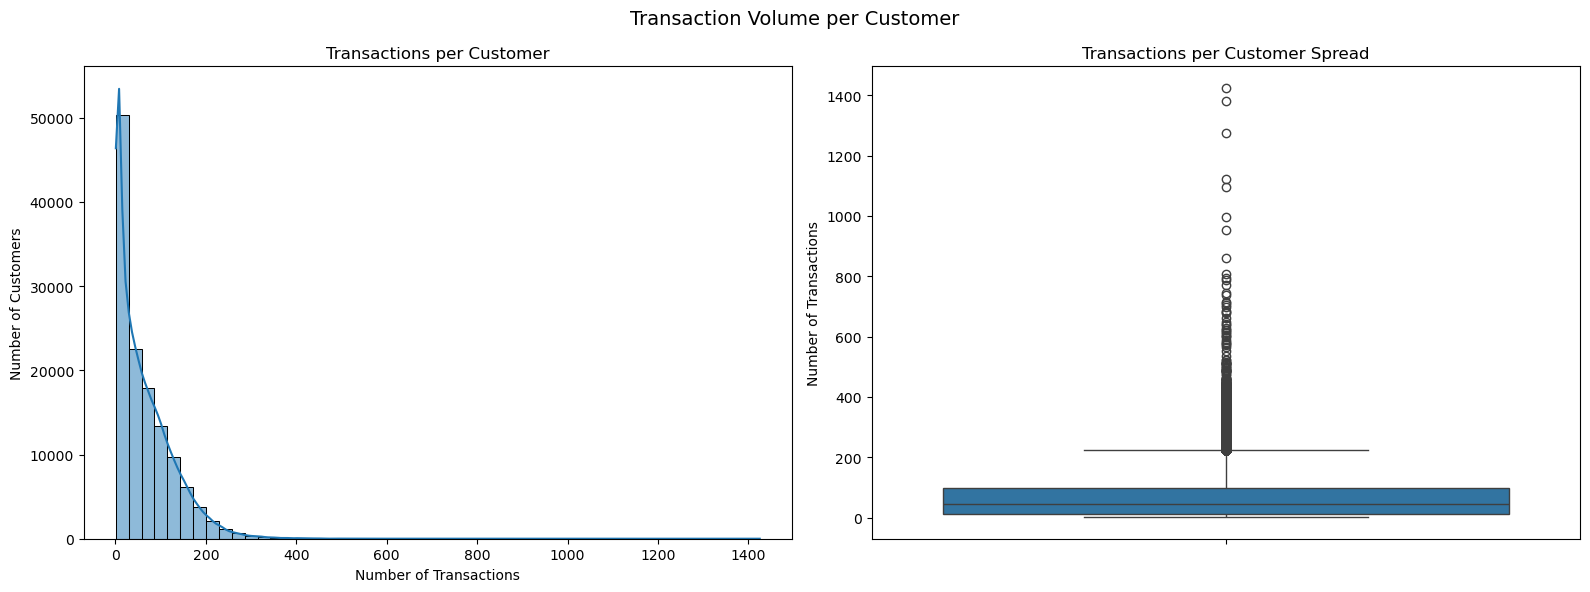

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df_txn_per_customer, x='txn_count', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Transactions per Customer')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(data=df_txn_per_customer, y='txn_count', ax=axes[1])
axes[1].set_title('Transactions per Customer Spread')
axes[1].set_ylabel('Number of Transactions')

plt.suptitle('Transaction Volume per Customer', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/txnpercustomers_a.png", dpi=150, bbox_inches='tight')
plt.show()

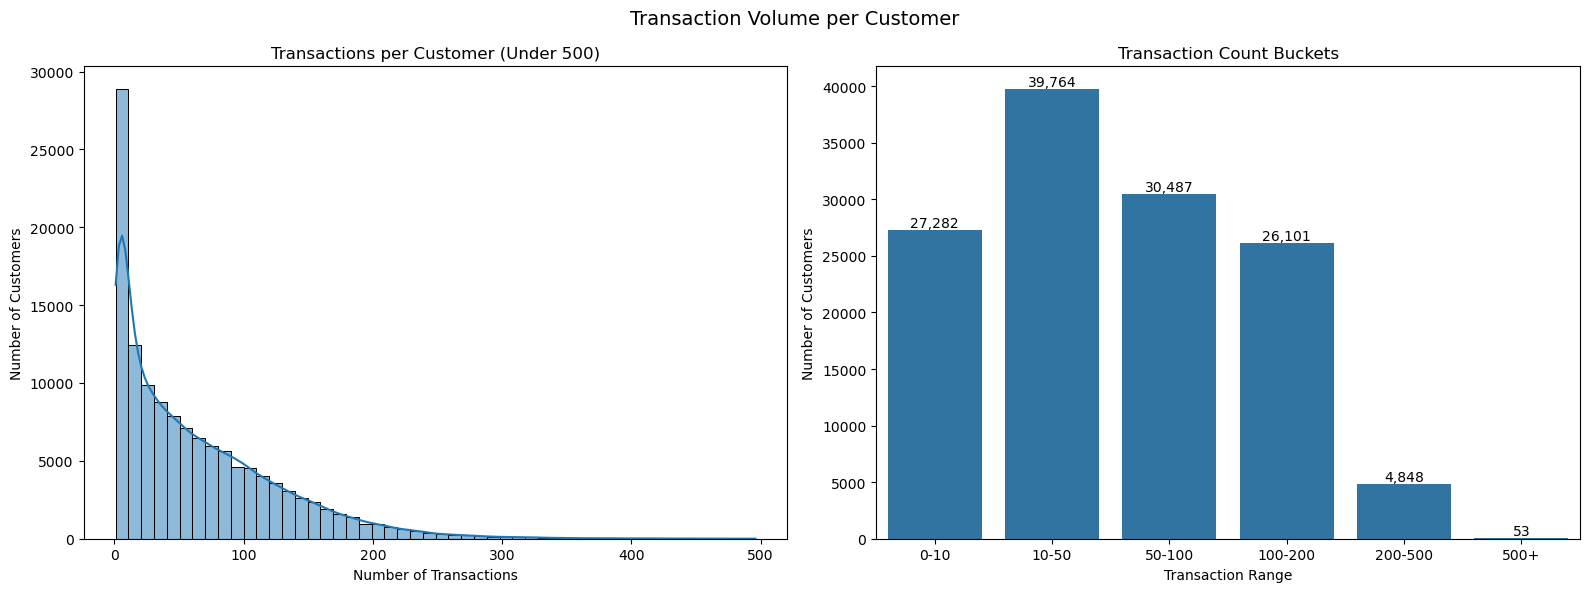

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

filtered_txn = df_txn_per_customer[df_txn_per_customer['txn_count'] < 500]
sns.histplot(data=filtered_txn, x='txn_count', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Transactions per Customer (Under 500)')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Number of Customers')

sns.barplot(data=df_txn_buckets, x='bucket', y='count', ax=axes[1])
axes[1].set_title('Transaction Count Buckets')
axes[1].set_xlabel('Transaction Range')
axes[1].set_ylabel('Number of Customers')
ax = axes[1]
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x):,}")

plt.suptitle('Transaction Volume per Customer', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/txnpercustomers_b.png", dpi=150, bbox_inches='tight')
plt.show()

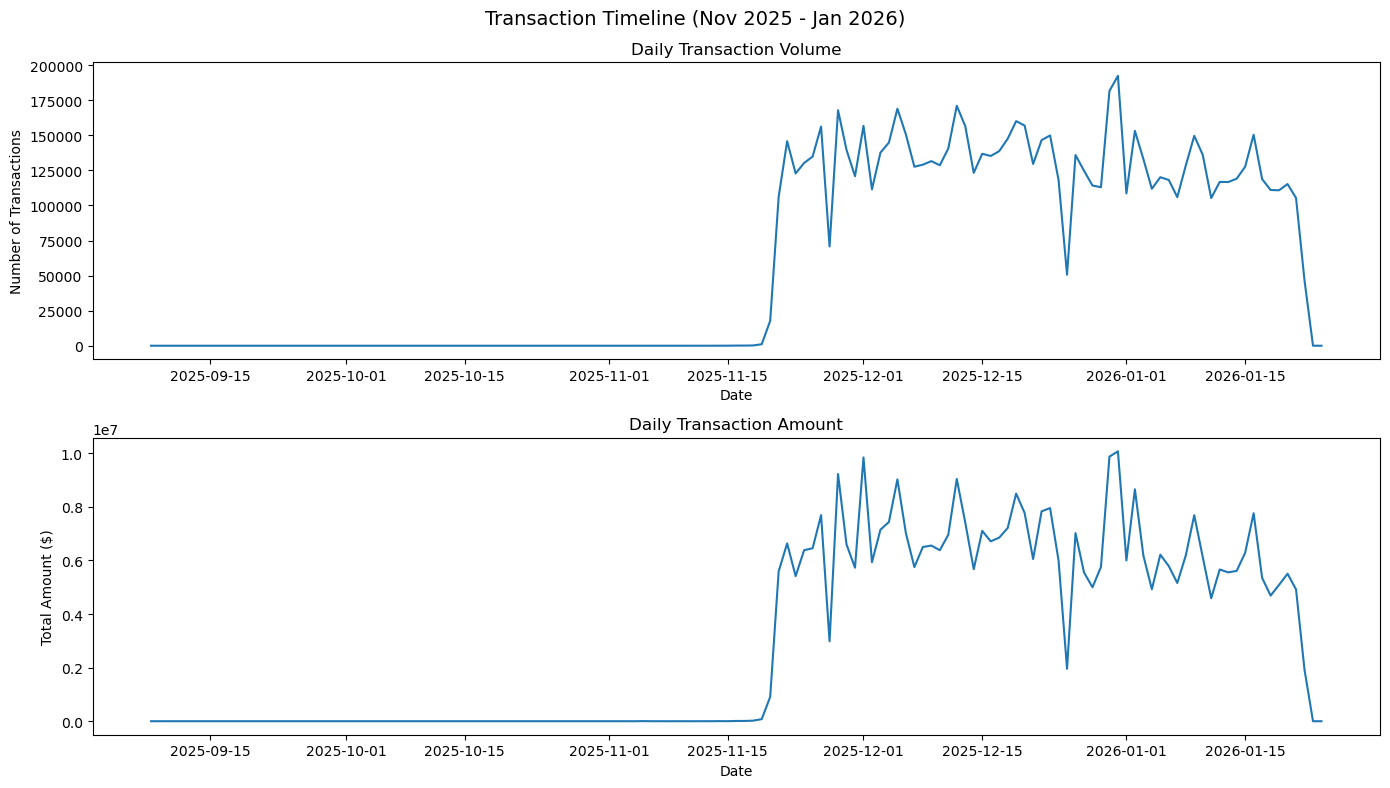

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_timeline['Transaction_Date'], df_timeline['count'])
axes[0].set_title('Daily Transaction Volume')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Transactions')

axes[1].plot(df_timeline['Transaction_Date'], df_timeline['total_amount'])
axes[1].set_title('Daily Transaction Amount')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Amount ($)')

plt.suptitle('Transaction Timeline (Nov 2025 - Jan 2026)', fontsize=14)
plt.tight_layout()
plt.show()

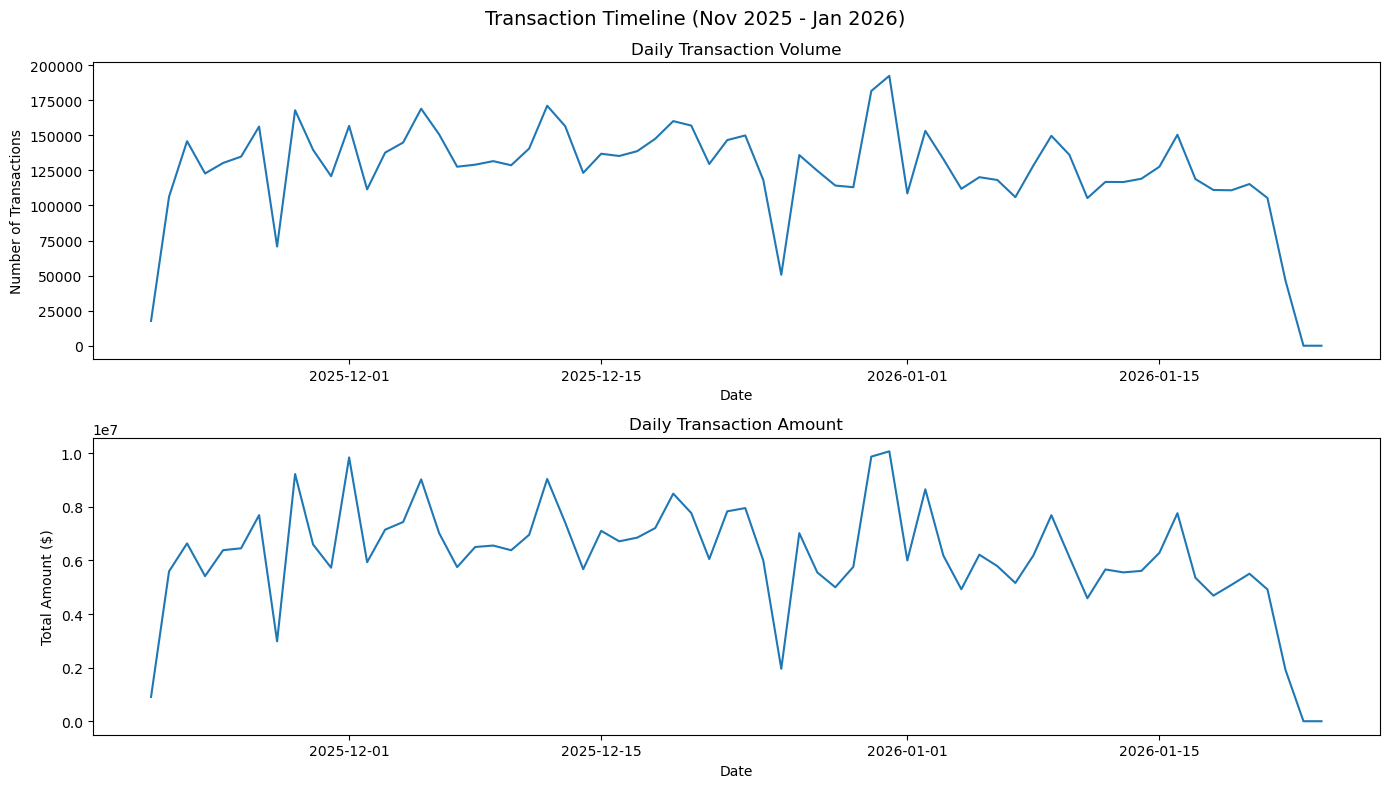

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

nov_onwards = df_timeline[df_timeline['Transaction_Date'] >= '2025-11-20']

axes[0].plot(nov_onwards['Transaction_Date'], nov_onwards['count'])
axes[0].set_title('Daily Transaction Volume')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Transactions')

axes[1].plot(nov_onwards['Transaction_Date'], nov_onwards['total_amount'])
axes[1].set_title('Daily Transaction Amount')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Amount ($)')

plt.suptitle('Transaction Timeline (Nov 2025 - Jan 2026)', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/txntimeline.png", dpi=150, bbox_inches='tight')
plt.show()

In [35]:
con.execute("""
    SELECT MIN(Transaction_Date) AS earliest, MAX(Transaction_Date) AS latest
    FROM transactions
""").fetchdf()

,earliest,latest
0,2025-09-08,2026-01-24


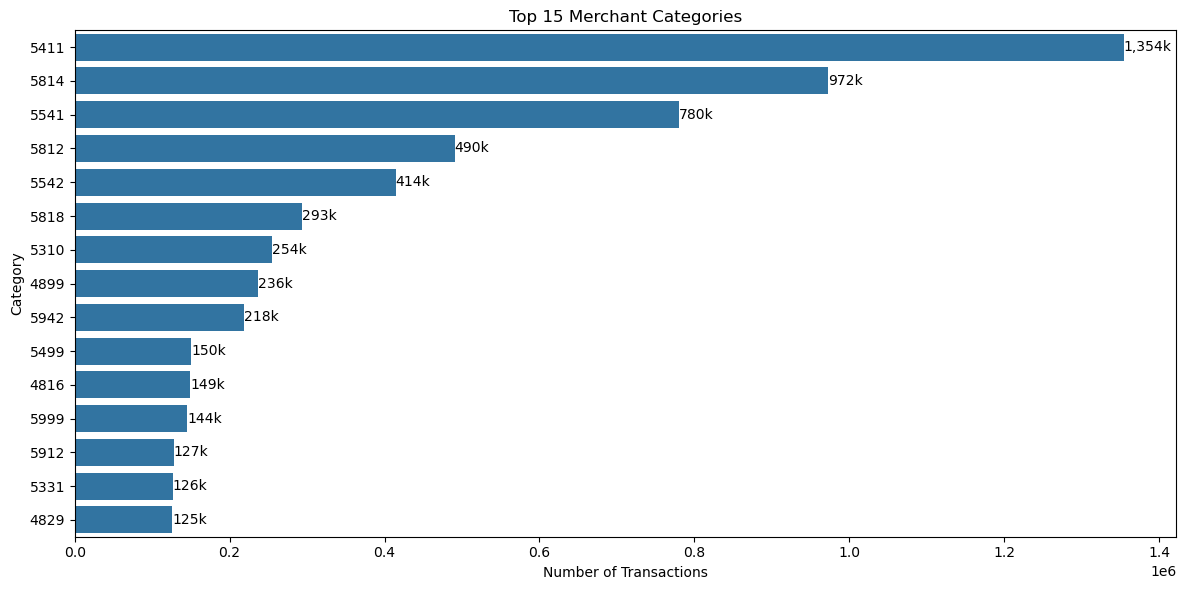

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_merchant_cat, x='count', y='Merchant_Category', ax=ax, orient='h')
ax.set_title('Top 15 Merchant Categories')
ax.set_xlabel('Number of Transactions')
ax.set_ylabel('Category')
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x)//1000:,}k")
plt.tight_layout()
fig.savefig("../figs/eda/txnmerchants.png", dpi=150, bbox_inches='tight')
plt.show()

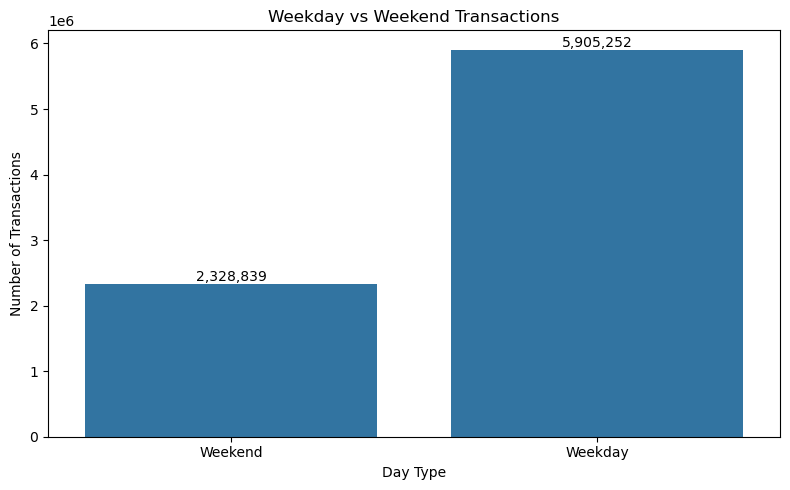

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_weekday_weekend, x='day_type', y='count', ax=ax)
ax.set_title('Weekday vs Weekend Transactions')
ax.set_xlabel('Day Type')
ax.set_ylabel('Number of Transactions')
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x):,}")
plt.tight_layout()
fig.savefig("../figs/eda/txndays.png", dpi=150, bbox_inches='tight')
plt.show()

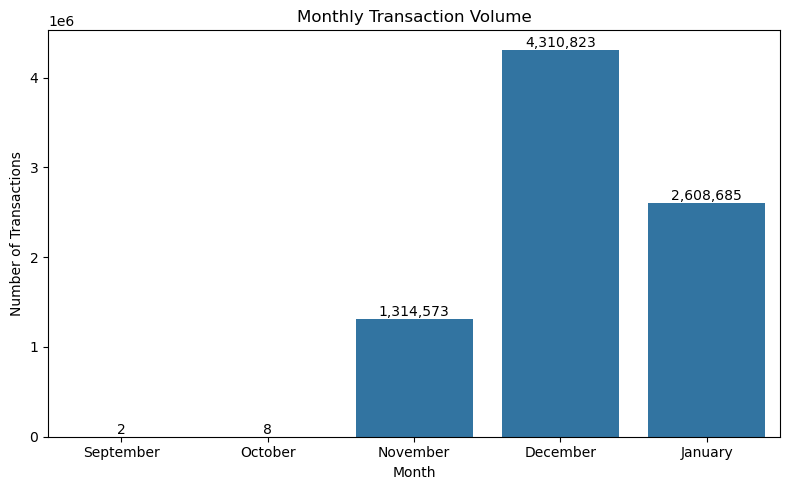

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
month_order = ['September', 'October', 'November', 'December', 'January']
sns.barplot(data=df_monthly, x='month', y='count', ax=ax, order=month_order)
ax.set_title('Monthly Transaction Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Transactions')
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x):,}")
plt.tight_layout()
fig.savefig("../figs/eda/txnmonths.png", dpi=150, bbox_inches='tight')
plt.show()

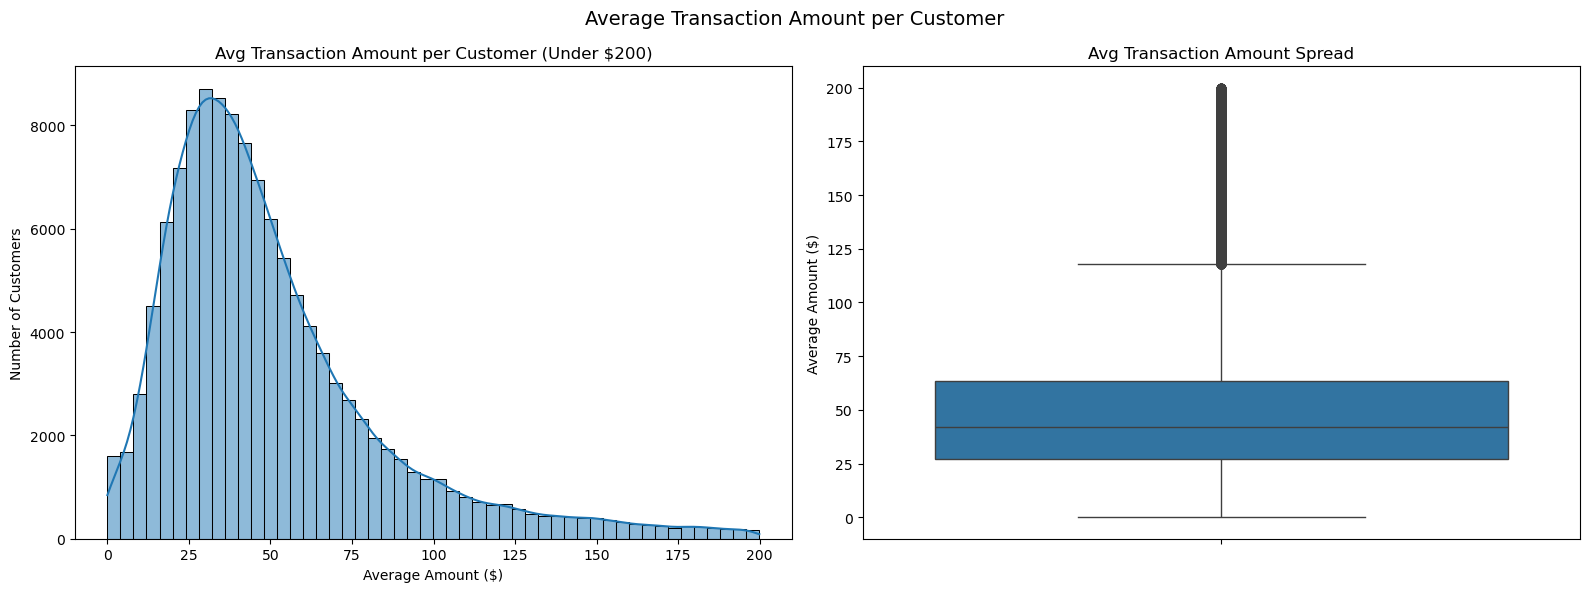

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

filtered_avg = df_avg_per_customer[df_avg_per_customer['avg_amount'] < 200]
sns.histplot(data=filtered_avg, x='avg_amount', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Avg Transaction Amount per Customer (Under $200)')
axes[0].set_xlabel('Average Amount ($)')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(data=filtered_avg, y='avg_amount', ax=axes[1])
axes[1].set_title('Avg Transaction Amount Spread')
axes[1].set_ylabel('Average Amount ($)')

plt.suptitle('Average Transaction Amount per Customer', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/txnamounts200.png", dpi=150, bbox_inches='tight')
plt.show()